In [2593]:
# Imports and global vars
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('ggplot')
pd.set_option('display.max_columns', 30) # dataset have 21 columns

cwd = Path.cwd()
project_dir = cwd.parent
data_dir = project_dir / 'data'

In [2594]:
raw_data = (data_dir / 'raw' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
# print(raw_data.is_file())
df = pd.read_csv(raw_data)

In [2595]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2596]:
row_count, column_count = df.shape
print(f"There are {row_count} rows and {column_count} columns in this dataset")

There are 7043 rows and 21 columns in this dataset


In [2597]:
# Guiding Questions for EDA
# 1. What does one row represent? # Answer : Each row represents one customer account. The row includes demographic attributes, subscribed services, account/contract information, billing charges, and the churn label.
# 2. What is the target column? # Answer : the 'Churn' column.
# 3. Is the target balanced or imbalanced? # Answer : The data is imbalanced - 73.4% are not Churn while 26.6% are (in numbers 5174 and 1869).
# 4. Which columns are numeric, categorical, or IDs? # Answer: 
#       customerID is an ID column.
#       tenure, MonthlyCharges are numeric columns.
#       TotalCharges dtype is str but should be numeric. this column stores blank values (' ') and requires cleaning.
#       SeniorCitizen stores integer values but it's categorical.
#       Rest of the columns are categorical.
# 5. Are there missing values or strange data types? # Answer : TotalCharges column stores blank values (' ') and requires investigation why.
# 6. Is there any feature that might not be available at prediction time? # Answer : 
# Churn is the target label and must be excluded during training and prediction. 
# customerID column is an identifier and should be excluded from modeling as well.
# All other columns are assumed to be avialable during prediction

In [2598]:
# Answer for Q3 - is the targget value balanced ?
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [2599]:
# Answer for Q4 - numeric vs categorical columns analysis
dtypes = df.dtypes
# print(f'All the dtypes in data frame :\n\n{dtypes}')
print(f"All the columns with non 'str' dtype :\n{dtypes[('str' != dtypes)]}")
print(f"All the columns with 'str' dtype :\n{dtypes[('str' == dtypes)]}")


print(f'\n\nSeniorCitizen have the following values\n{df['SeniorCitizen'].value_counts()}')
print(f'\n\nTotalCharges have the following values\n{df['TotalCharges'].value_counts()}')
print(f'\nMeaning : SeniorCitizen is actually categorical and TotalCharges is numeric')

numeric_columns  = dtypes['str' != dtypes].index.to_list()
category_columns = dtypes['str' == dtypes].index.to_list()

numeric_columns.remove('SeniorCitizen')
numeric_columns.append('TotalCharges')

category_columns.remove('TotalCharges')
category_columns.append('SeniorCitizen')


print(f'\nnumeric columns are {numeric_columns}')
print(f'\ncategorical columns are {category_columns}')

All the columns with non 'str' dtype :
SeniorCitizen       int64
tenure              int64
MonthlyCharges    float64
dtype: object
All the columns with 'str' dtype :
customerID          str
gender              str
Partner             str
Dependents          str
PhoneService        str
MultipleLines       str
InternetService     str
OnlineSecurity      str
OnlineBackup        str
DeviceProtection    str
TechSupport         str
StreamingTV         str
StreamingMovies     str
Contract            str
PaperlessBilling    str
PaymentMethod       str
TotalCharges        str
Churn               str
dtype: object


SeniorCitizen have the following values
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


TotalCharges have the following values
TotalCharges
20.2      11
          11
19.75      9
19.9       8
20.05      8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, Length: 6531, dtype: int64

Meaning : SeniorCitizen is actually categorical 

In [2600]:
# Answer Q5 - missing values, duplicates and strange values

# duplicated rows and or duplicated data for customers
print(df.duplicated().any())
print(df['customerID'].duplicated().any())

False
False


In [2601]:
# Missing values
print(df.isna().any(axis=0)) # nan values check
print(df.eq(' ').sum())      # blank values check 

customerID          False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Total

In [2602]:
# missing values at TotalCharges investigation
# Since MonthlyCharges * tenure =~ TotalCharges
# TotalCharges == 0 --->  tenure == 0 ?
rows_with_blan_tc = df.eq(' ').any(axis=1)
print(df.loc[rows_with_blan_tc, 'tenure'])

488     0
753     0
936     0
1082    0
1340    0
3331    0
3826    0
4380    0
5218    0
6670    0
6754    0
Name: tenure, dtype: int64


In [2603]:
## TotalCharges Investigation
# - There are 11 blank values in the TotalCharges. There are no any missing values except those in this dataset.
# - Tenure is 0 For all rows with blank values at TotalCharges.
# - TotalCharges are missing in those instances becuase the tenure is less than a month and no charges were made.
# cleaning options:
#   - Setting TotalCharges to match MonthlyCharges
#   - Convert all blank values to nan and impute them later on
#   - Delete rows entirely
#   - TotalCharges = 0
# - Since MonthlyCharges * tenure ~= TotalCharges (tc is the accumlated charges for a customer for the entire subscription period),
#   0 tenure ---> TotalCharges = 0.
#   Cleaning the data would require to cast entire tc column as float with missing values as 0.

In [2604]:
print(df.info())
df.head(n=10)

# Data Dictionary 
# | Column | Meaning | Raw dtype | ML role | Notes |
# |---|---|---:|---|---|
# | customerID | Unique customer identifier   | str | exclude | ID column, not useful for generalization |
# | gender | Customer gender (Male or Female) | str | binary categorical | need to inspect |
# | SeniorCitizen | Whether customer is senior citizen | int | binary categorical | Stored as 0/1 |
# | Partner | Whether the customer has a partner or not (Yes, No) | str | binary categorical | need to inspect |
# | Dependents | Whether the customer has dependents or not (Yes, No) | str | binary categorical | need to inspect |
# | tenure | Number of months the customer has stayed with the company | int | numeric feature | Important customer lifecycle variable |
# | PhoneService | Whether the customer has a phone service or not (Yes, No) | str | binary categorical | need to inspect |
# | MultipleLines | Whether the customer has multiple lines or not (Yes, No, No phone service) | str | non binary categorical | need to inspect |
# | InternetService | Customer’s internet service provider (DSL, Fiber optic, No) | str | non binary categorical | need to inspect |
# | OnlineSecurity | Whether the customer has online security or not (Yes, No, No internet service) | str | non binary categorical | need to inspect |
# | OnlineBackup | Whether the customer has online backup or not (Yes, No, No internet service) | str | non binary categorical | need to inspect |
# | DeviceProtection | Whether the customer has device protection or not (Yes, No, No internet service) | str | non binary categorical | need to inspect |
# | TechSupport | Whether the customer has tech support or not (Yes, No, No internet service) | str | non binary categorical | need to inspect |
# | StreamingTV | Whether the customer has streaming TV or not (Yes, No, No internet service) | str | non binary categorical | need to inspect |
# | StreamingMovies | Whether the customer has streaming movies or not (Yes, No, No internet service) | str | non binary categorical | need to inspect |
# | Contract | The contract term of the customer (Month-to-month, One year, Two year) | str | non binary categorical | need to inspect |
# | PaperlessBilling | Whether the customer has paperless billing or not (Yes, No) | str | binary categorical | need to inspect |
# | PaymentMethod | The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card) | str | non binary categorical | need to inspect |
# | MonthlyCharges | Monthly bill amount | float | numeric feature | Numeric |
# | TotalCharges | Total accumulated charges | object | numeric feature | Needs conversion; blanks with tenure=0 become 0 |
# | Churn | Whether customer churned | str | target | Binary target: Yes/No |



<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [2605]:
# EDA 

# filling all missing tc with 0's as explained earlier so I can preform EDA
clean_df = df.copy()
clean_df['TotalCharges']  = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')
clean_df.fillna(0, inplace=True)

# casting SeniorCitizen to str
clean_df = clean_df.astype({"SeniorCitizen":"str"})

# Interesting columns : 
# tenure, MonthlyCharges & TotalCharges, Contract, PaymentMethod, TechSupport (or other services).

# tenure
# -----------------------------
# Question
# How does churn rate change as tenure increases?
# Hypothesis
# low tenure customers are likelly to churn since they have low attachment to the company while high tenure customers may fell more attached.
# Update : correct. high churn rates for low tenure customers.


# MonthlyCharges & TotalCharges
# -----------------------------
# Question
# High MonthlyCharges/TotalCharges make churn more likely? 
# Hypothesis
# Customers with higher monthly charges/ total charge may churn more often because they may be more sensitive to price or more likely to compare alternatives.
# Update : low mc values have low churn rates while medium-high (68-108) mc have 40%~ churn rates.

# Question
# Is `TotalCharges` have linear connection to 'MonthlyCharges', tenure ? (tc =~ mc * tenure ? )
# Hypothesis
# Considering things like : hidden fees, discounts, commision on different payment type,which are missing from the dataset, 
# I expect some differences.

# Question
# Future check :
# Differences in tc vs mc*tenure impact on churn.
# Hypothesis
# Customers with MonthlyCharges * tenure > TotalCharges have somesort of discount ence bigger attachment to the company. less likely to churn

# Contract
# -----------------------------
# Question
# Does churn rate differ by contract type ? 
# Hypothesis
# Month-to-month customers are expected to have higher churn rates because they have lower commitment than one-year or two-year customers.


# PaymentMethod
# -----------------------------
# Question
# Customers with non automatic payment methods are likely to churn ? 
# Hypothesis
# Customers with non automatic payment method are more exposed to subscription costs and therfore expose to churn decision more.


# TechSupport
# -----------------------------
# Question
# Customers without TechSupport are more likely to churn ? 
# Hypothesis
# Customers without TechSupport are more likely to churn since they are more prone to frustration over issues that require tech support. 


In [2606]:
# Auxiliry functions
def column_by_churn(df, column_name, bins=None, series_labels=['All', 'Churned', 'NotChurned']):
    is_numeric = df.dtypes[column_name] != 'str'
    
    column_series = [df[column_name], df.loc[df['Churn'] == 'Yes', column_name] , df.loc[clean_df['Churn'] == 'No' ,column_name]]
    for i in range(len(column_series)):
        if is_numeric:
            column_bins = bins
            column_series[i] = pd.cut(column_series[i], bins=column_bins)
            
        column_series[i] = column_series[i].value_counts().rename(series_labels[i])
    
    column_by_churn_df = pd.concat(
        [*column_series],
        axis=1,
    ).sort_index()
    
    return column_by_churn_df


def churn_by_column(df, column_name, bins=None):
    is_numeric = df.dtypes[column_name] != 'str'
    col_grp_by = pd.cut(df[column_name], bins=bins) if is_numeric else df[column_name]
    
    churn_by_col_df = df.groupby(col_grp_by)['Churn'] \
                        .value_counts() \
                        .sort_index(level=0, ascending=True) \
                        .unstack()
    
    churn_by_col_df['Total'] = churn_by_col_df['Yes'] + churn_by_col_df['No']
    return churn_by_col_df
    

           All  Churned  NotChurned
tenure                             
(0, 6]    1470      784         686
(6, 12]    705      253         452
(12, 24]  1024      294         730
(24, 36]   832      180         652
(36, 48]   762      145         617
(48, 72]  2239      213        2026


array([[<Axes: title={'center': 'All Customers Tenure'}, xlabel='tenure (months)', ylabel='count'>,
        <Axes: title={'center': 'Churned Customers Tenure'}, xlabel='tenure (months)', ylabel='count'>,
        <Axes: title={'center': 'Not Churned Customers Tenure'}, xlabel='tenure (months)', ylabel='count'>]],
      dtype=object)

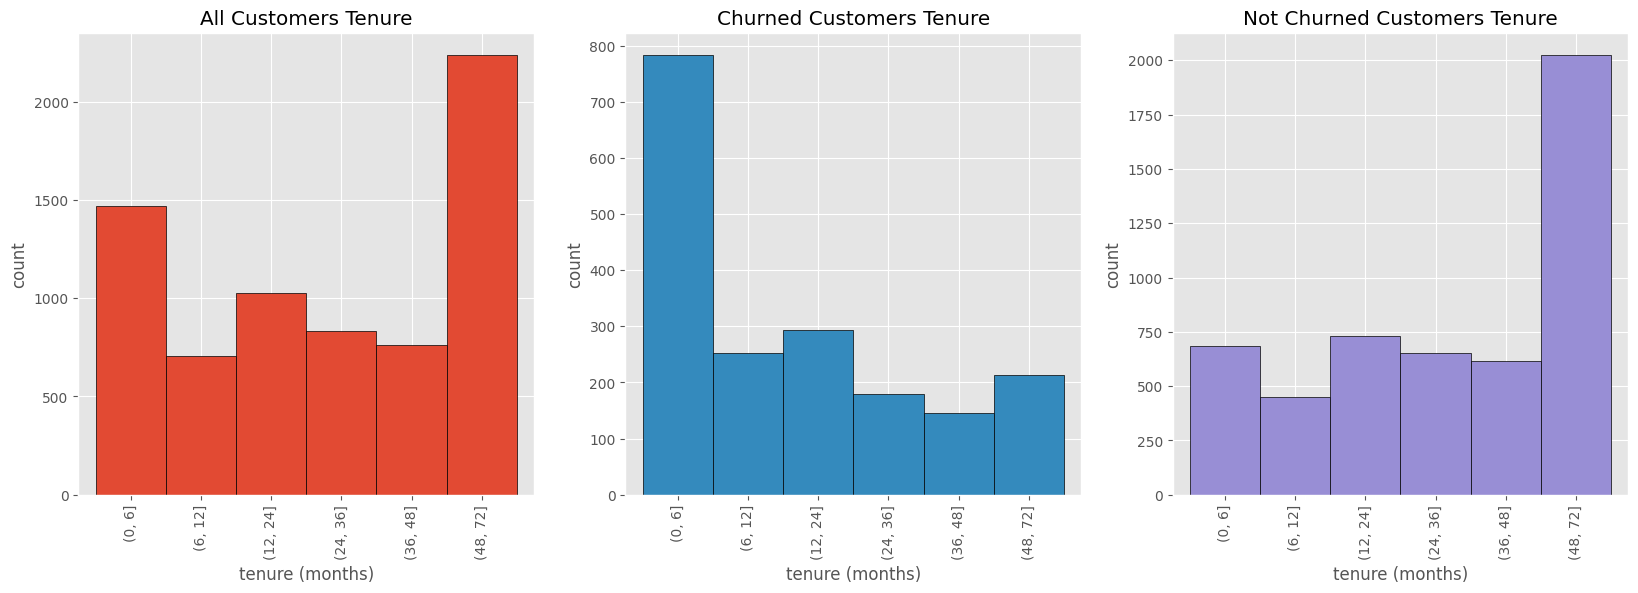

In [2645]:
# tenure
# -----------------------------
# tenure distribution
column_name = 'tenure'
series_labels = ['All', 'Churned', 'NotChurned']
tenure_bin_boundaries = [0, 6, 12, 24, 36, 48, clean_df['tenure'].max()]

_, tenure_bins = np.histogram(clean_df['tenure'], bins=tenure_bin_boundaries)


tenure_bins_df = column_by_churn(clean_df, column_name, bins=tenure_bins)
print(tenure_bins_df)
   
tenure_bins_df.plot(kind='bar',
                    subplots=True,
                    figsize=(20,6),
                    layout=(1,3),
                    width=1, 
                    edgecolor='black',
                    xlabel='tenure (months)',
                    ylabel='count',
                    title=['All Customers Tenure', 'Churned Customers Tenure', 'Not Churned Customers Tenure'],
                    legend=False
                   )

In [2608]:
for label in series_labels:
    print(f"tenure percentile for {label} customers:\n----------------------------------------\n{tenure_bins_df[label] / tenure_bins_df[label].sum()}")
    print('\n')

tenure percentile for All customers:
----------------------------------------
tenure
(0, 6]      0.209044
(6, 12]     0.100256
(12, 24]    0.145620
(24, 36]    0.118316
(36, 48]    0.108362
(48, 72]    0.318402
Name: All, dtype: float64


tenure percentile for Churned customers:
----------------------------------------
tenure
(0, 6]      0.419476
(6, 12]     0.135367
(12, 24]    0.157303
(24, 36]    0.096308
(36, 48]    0.077582
(48, 72]    0.113965
Name: Churned, dtype: float64


tenure percentile for NotChurned customers:
----------------------------------------
tenure
(0, 6]      0.132868
(6, 12]     0.087546
(12, 24]    0.141391
(24, 36]    0.126283
(36, 48]    0.119504
(48, 72]    0.392408
Name: NotChurned, dtype: float64




In [2609]:
# Observations :
# Most of the customers are either : long time customers (48+ months) or new customers (6 months as most).
# Another noteable group is the 12-24 months of tenure customers.
# 0-6 group is 20% of all customers, 48+ group is 31% of all customers while 12-24 group is 15% of all customers.
# Most of the customers who churned are new customers (6 months at most), about 42%.
# Most of the customers who haven't churned are long time customers (48+ months), about 39%.

<Axes: xlabel='tenure (months)', ylabel='count'>

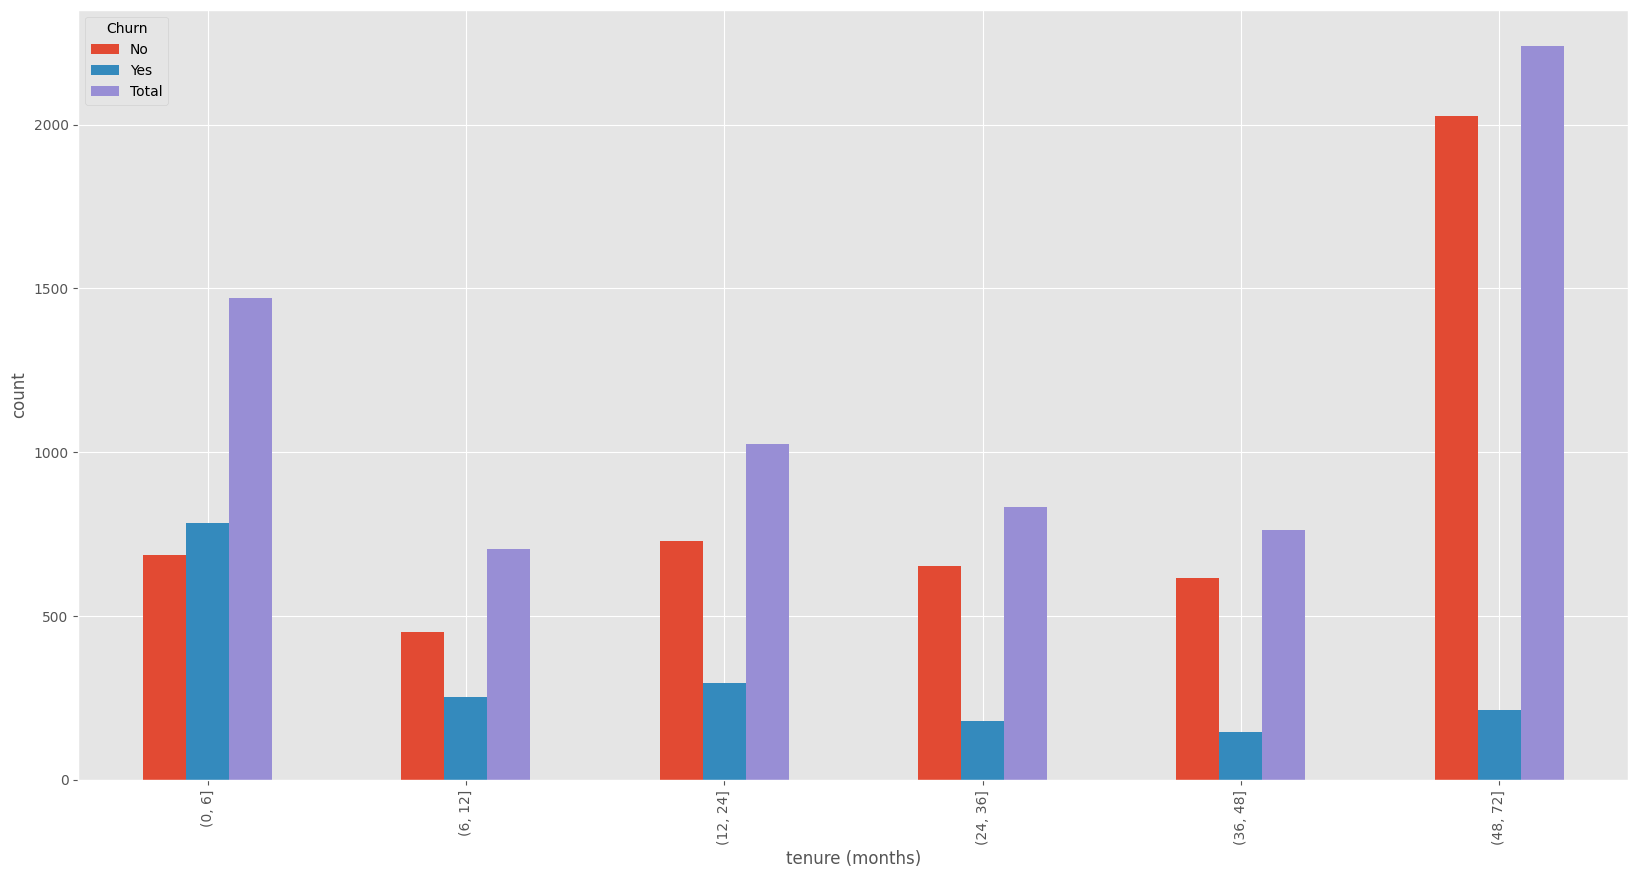

In [2610]:
# churn distribution by tenure
churn_by_tenure_bins_df = churn_by_column(clean_df, column_name, bins=tenure_bin_boundaries)

churn_by_tenure_bins_df.plot(kind='bar',
                             # subplots=True,
                             figsize=(20,10),
                             xlabel='tenure (months)',
                             ylabel='count'
                            )

churn rate for bin (0, 6] is : 53.33%
churn rate for bin (6, 12] is : 35.89%
churn rate for bin (12, 24] is : 28.71%
churn rate for bin (24, 36] is : 21.63%
churn rate for bin (36, 48] is : 19.03%
churn rate for bin (48, 72] is : 9.51%


<Axes: xlabel='tenure (months)', ylabel='rate'>

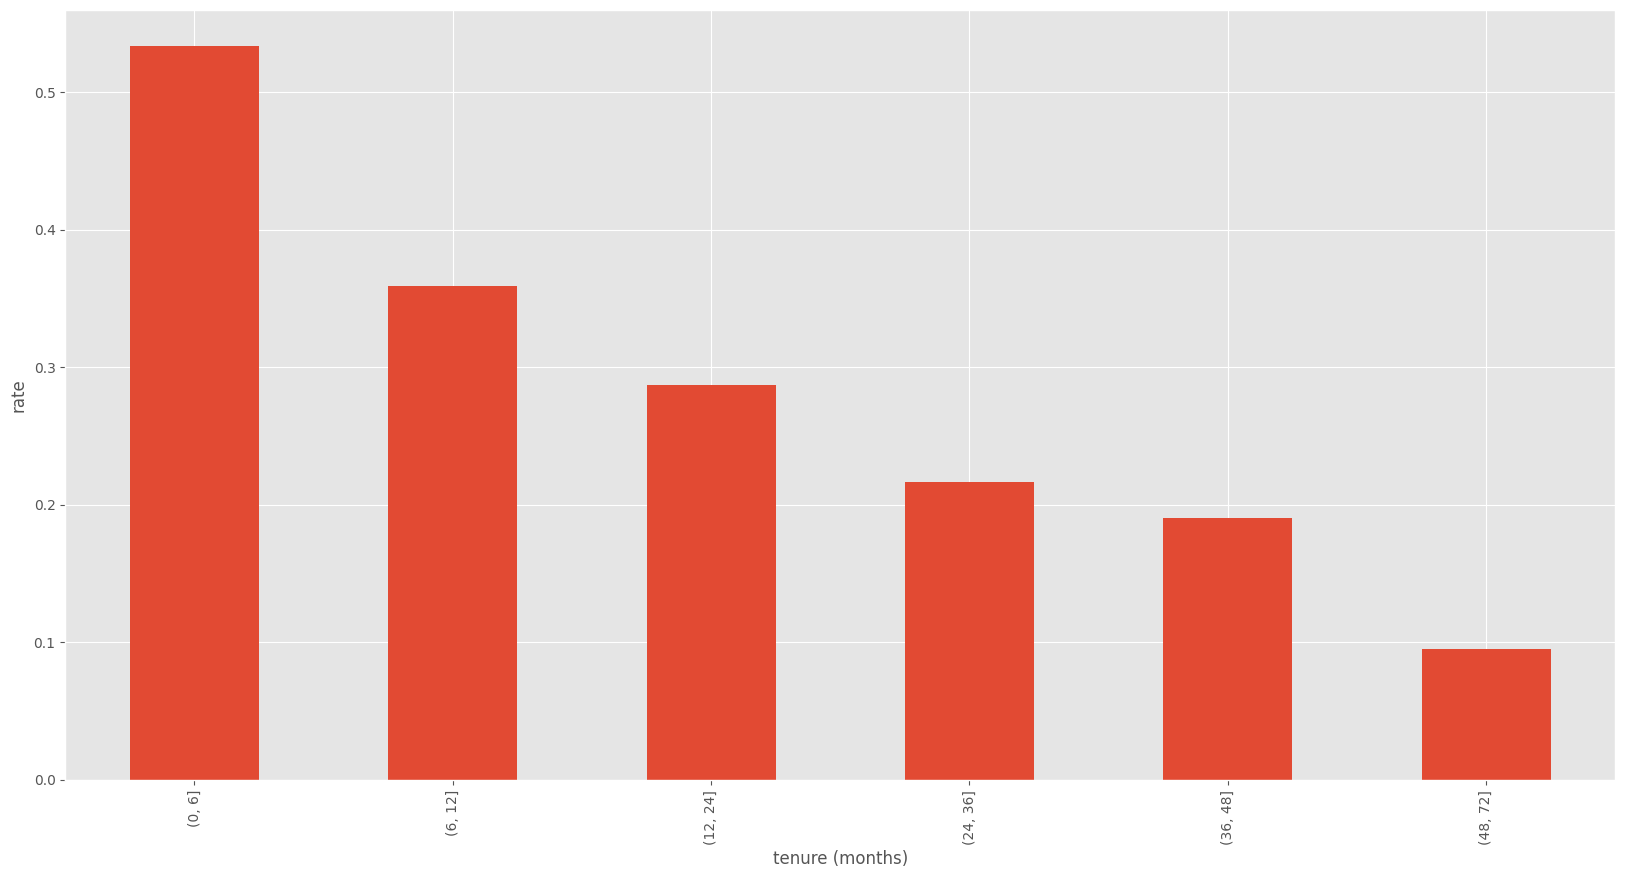

In [2642]:
for i in churn_by_tenure_bins_df.index:
    churn_rate = churn_by_tenure_bins_df.loc[i,'Yes'] / churn_by_tenure_bins_df.loc[i, 'Total']
    print(f"churn rate for bin {i} is : {churn_rate*100:.2f}%")

churn_rate = churn_by_tenure_bins_df['Yes'] / churn_by_tenure_bins_df['Total']
churn_rate.plot(kind='bar',
                             # subplots=True,
                             figsize=(20,10),
                             xlabel='tenure (months)',
                             ylabel='rate'
                            )

In [2612]:
# Observations :
# Churn rate will decrease as tenure increases monotonically while being highest on the 0-6 months customers.

<Axes: ylabel='Frequency'>

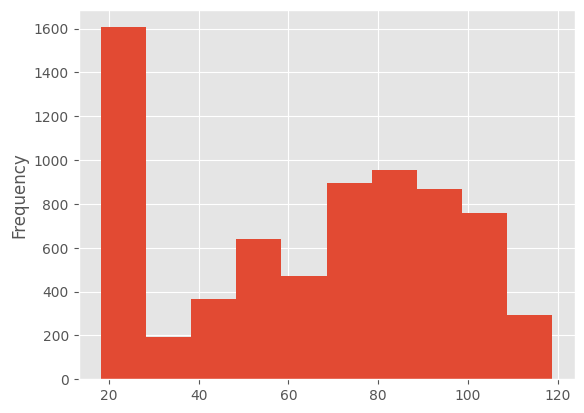

In [2613]:
# MonthlyCharges & TotalCharges
# -----------------------------
column_name = 'MonthlyCharges'
series_labels = ['All', 'Churned', 'NotChurned']
num_of_bins = 10 
_, mc_bins = np.histogram(clean_df['MonthlyCharges'], bins=num_of_bins)
clean_df['MonthlyCharges'].plot(kind='hist', bins=mc_bins)

<Axes: xlabel='Monthly Charges', ylabel='count'>

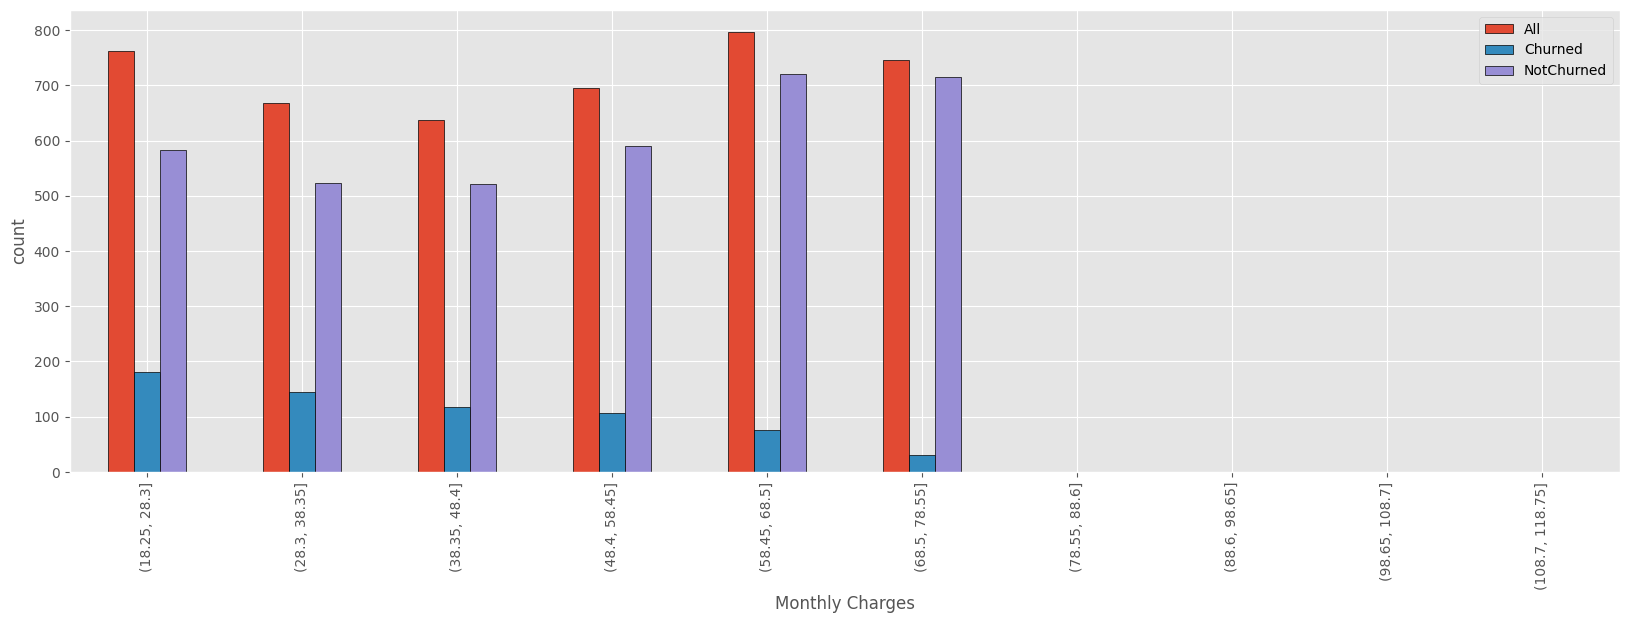

In [2798]:
mc_bin_hist_df = column_by_churn(clean_df, column_name, bins=mc_bins, series_labels=series_labels)


mc_bin_hist_df.plot(kind='bar',
                    # subplots=True,
                    figsize=(20,6),
                    # layout=(1,3),
                    width=0.5, 
                    edgecolor='black',
                    xlabel='Monthly Charges',
                    ylabel='count',
                    # title=['All Customers Monthly Charges', 'Churned Monthly Charges', 'Not Churned Monthly Charges'],
                    legend=True
                   )

In [2615]:
for label in series_labels:
    print(f"mc percentile for {label} customers:\n----------------------------------------\n{mc_bin_hist_df[label] / mc_bin_hist_df[label].sum()}")
    print('\n')


mc percentile for All customers:
----------------------------------------
MonthlyCharges
(18.25, 28.3]      0.227918
(28.3, 38.35]      0.027123
(38.35, 48.4]      0.051832
(48.4, 58.45]      0.090883
(58.45, 68.5]      0.067310
(68.5, 78.55]      0.126811
(78.55, 88.6]      0.135331
(88.6, 98.65]      0.123970
(98.65, 108.7]     0.107072
(108.7, 118.75]    0.041750
Name: All, dtype: float64


mc percentile for Churned customers:
----------------------------------------
MonthlyCharges
(18.25, 28.3]      0.079187
(28.3, 38.35]      0.030498
(38.35, 48.4]      0.063670
(48.4, 58.45]      0.081327
(58.45, 68.5]      0.028892
(68.5, 78.55]      0.186731
(78.55, 88.6]      0.189941
(88.6, 98.65]      0.171215
(98.65, 108.7]     0.145532
(108.7, 118.75]    0.023007
Name: Churned, dtype: float64


mc percentile for NotChurned customers:
----------------------------------------
MonthlyCharges
(18.25, 28.3]      0.281655
(28.3, 38.35]      0.025904
(38.35, 48.4]      0.047555
(48.4, 58.45]     

In [2616]:
print('percent of customers mc is in between 18.25-28.3:')
for label in series_labels:
    percent = (mc_bin_hist_df.iloc[0][label] /mc_bin_hist_df[label].sum())
    print(f"given {label} customers,{percent:.2f}%")
    
print("\n")

print('percent of customers mc is in  between 68.5-108.7:')
for label in series_labels:
    percent = (mc_bin_hist_df.iloc[5:9][label] /mc_bin_hist_df[label].sum()).sum()
    print(f"given {label} customers,{percent:.2f}%")

percent of customers mc is in between 18.25-28.3:
given All customers,0.23%
given Churned customers,0.08%
given NotChurned customers,0.28%


percent of customers mc is in  between 68.5-108.7:
given All customers,0.49%
given Churned customers,0.69%
given NotChurned customers,0.42%


In [2617]:
# Observations:
# - Customers mc is divded to several major groups : 
# - 18.25 - 28.3 with 23% the biggest group
# - 68.5 - 78.55, 78.55 - 88.6, 88.6 - 98.65, 98.65 - 108.7 medium sized groups with 10%-13% each.
# - For churned customers, 68.5 - 78.55, 78.55 - 88.6, 88.6 - 98.65, 98.65 - 108.7, are the biggest groups with 14.5%-19% each.
# - 69% of the churned customers are in the 68.5-108.7
# - For non churned customers, distribution is similar to all customers with 18.25 - 28.3 have a bigger share of 28%.

<Axes: xlabel='MonthlyCharges'>

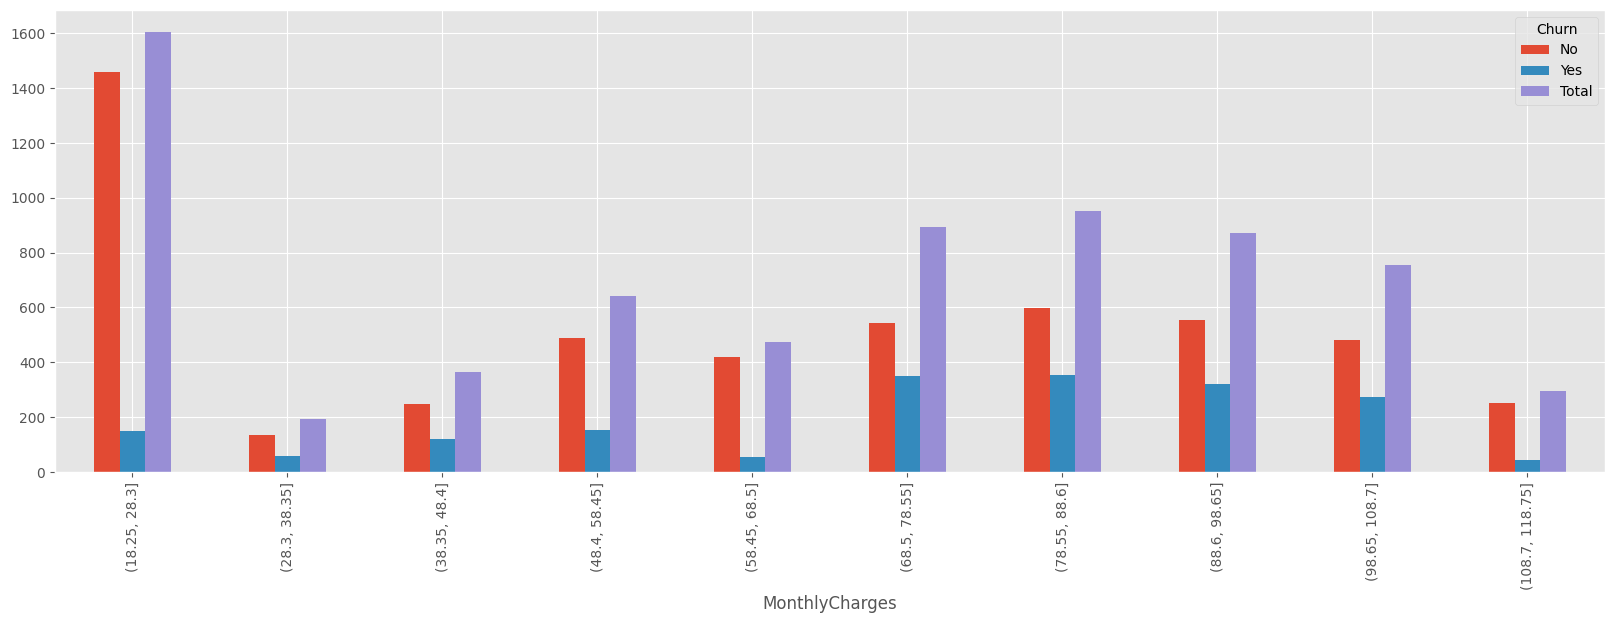

In [2618]:
# churn distribution by monthly charges
churn_by_mc_df = churn_by_column(clean_df, column_name, bins=mc_bins)

churn_by_mc_df.plot(kind='bar',
                    # subplots=True,
                    figsize=(20,6),
                   )

In [2619]:
for i in churn_by_mc_df.index:
    churn_rate = churn_by_mc_df.loc[i,'Yes'] / churn_by_mc_df.loc[i,'Total']
    print(f"churn rate for bin {i} is : {churn_rate*100:.2f}%")
    print(f"total - {churn_by_mc_df.loc[i,'Total']}")

churn rate for bin (18.25, 28.3] is : 9.22%
total - 1605
churn rate for bin (28.3, 38.35] is : 29.84%
total - 191
churn rate for bin (38.35, 48.4] is : 32.60%
total - 365
churn rate for bin (48.4, 58.45] is : 23.75%
total - 640
churn rate for bin (58.45, 68.5] is : 11.39%
total - 474
churn rate for bin (68.5, 78.55] is : 39.08%
total - 893
churn rate for bin (78.55, 88.6] is : 37.25%
total - 953
churn rate for bin (88.6, 98.65] is : 36.66%
total - 873
churn rate for bin (98.65, 108.7] is : 36.07%
total - 754
churn rate for bin (108.7, 118.75] is : 14.63%
total - 294


In [2620]:
# Observations :
# Churn rate by mc have several majority groups:
# 68.5 - 78.55, 78.55 - 88.6, 88.6 - 98.65, 98.65 - 108.7 groups with 36-39% each and 28.3- 38.35, 38.35-48.4 with 30% and 32.6%.
# the latter seems to stem from the fact the the overall count for these groups is quite low (191 & 365).

<Axes: ylabel='Frequency'>

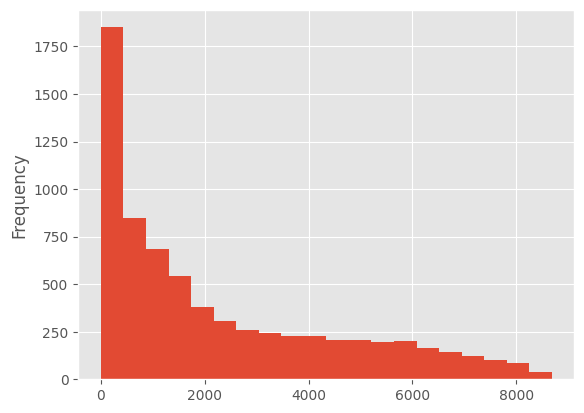

In [2621]:
# TotalCharges
# -----------------------------
column_name = 'TotalCharges'
series_labels = ['All', 'Churned', 'NotChurned']
num_of_bins = 20
_, tc_bins = np.histogram(clean_df['TotalCharges'], bins=num_of_bins)

clean_df['TotalCharges'].plot(kind='hist',bins=tc_bins)

array([[<Axes: title={'center': 'All Customers Total Charges'}, xlabel='Total Charges', ylabel='count'>,
        <Axes: title={'center': 'Churned Total Charges'}, xlabel='Total Charges', ylabel='count'>,
        <Axes: title={'center': 'Not Churned Total Charges'}, xlabel='Total Charges', ylabel='count'>]],
      dtype=object)

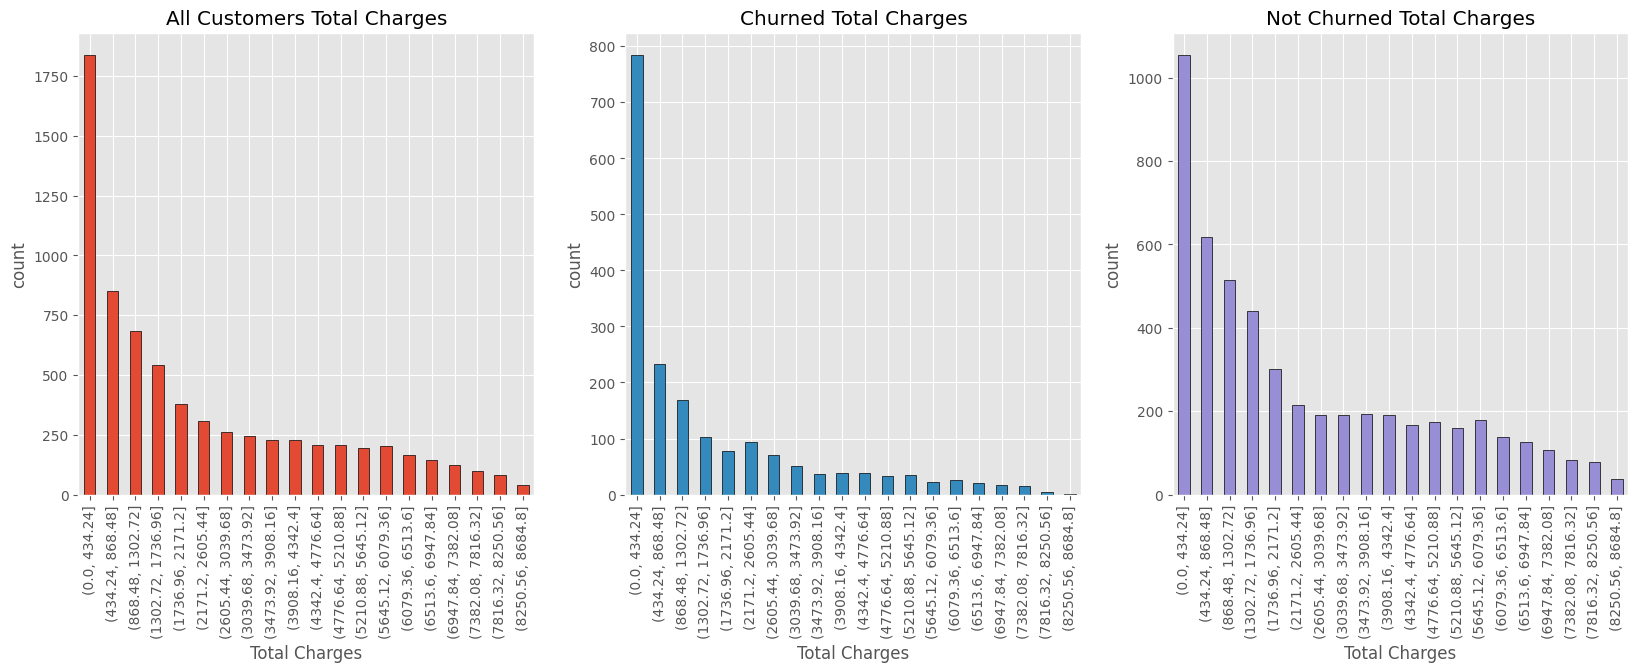

In [2622]:
tc_bin_hist_df = column_by_churn(clean_df, column_name, bins=tc_bins, series_labels=series_labels)

tc_bin_hist_df.plot(kind='bar',
                    subplots=True,
                    figsize=(20,6),
                    layout=(1,3), 
                    edgecolor='black',
                    xlabel='Total Charges',
                    ylabel='count',
                    title=['All Customers Total Charges', 'Churned Total Charges', 'Not Churned Total Charges'],
                    legend=False
                   )

In [2623]:
for label in series_labels:
    print(f"tc percentile for {label} customers:\n----------------------------------------\n{tc_bin_hist_df[label] / tc_bin_hist_df[label].sum()}")
    print('\n')

tc percentile for All customers:
----------------------------------------
TotalCharges
(0.0, 434.24]         0.261661
(434.24, 868.48]      0.120876
(868.48, 1302.72]     0.097127
(1302.72, 1736.96]    0.077361
(1736.96, 2171.2]     0.053754
(2171.2, 2605.44]     0.043658
(2605.44, 3039.68]    0.036974
(3039.68, 3473.92]    0.034556
(3473.92, 3908.16]    0.032708
(3908.16, 4342.4]     0.032708
(4342.4, 4776.64]     0.029437
(4776.64, 5210.88]    0.029437
(5210.88, 5645.12]    0.027588
(5645.12, 6079.36]    0.028726
(6079.36, 6513.6]     0.023464
(6513.6, 6947.84]     0.020762
(6947.84, 7382.08]    0.017776
(7382.08, 7816.32]    0.014078
(7816.32, 8250.56]    0.011803
(8250.56, 8684.8]     0.005546
Name: All, dtype: float64


tc percentile for Churned customers:
----------------------------------------
TotalCharges
(0.0, 434.24]         0.420011
(434.24, 868.48]      0.124666
(868.48, 1302.72]     0.090423
(1302.72, 1736.96]    0.055110
(1736.96, 2171.2]     0.041734
(2171.2, 2605.44]  

In [2624]:
# Observations :
# Total charges distribution is roughly exponential decrease as tc rises (also for churned and not churned customers).
# For churned customers, 54% tc are between 0-868.48 tc.
# Not churned customers are more evenly distributed as 54% are between 0 and 2171.2.

<Axes: xlabel='TotalCharges'>

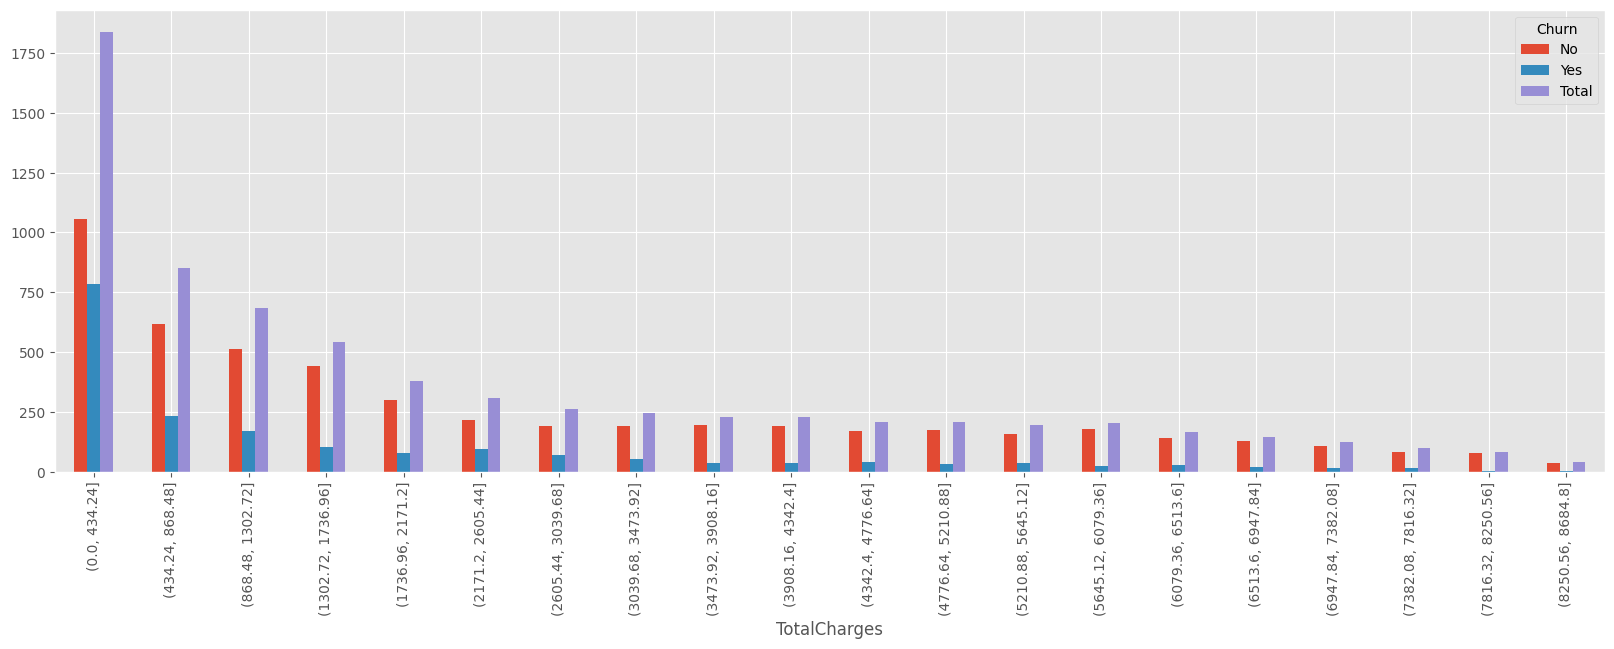

In [2625]:
# churn distribution by total charges
churn_by_tc_df = churn_by_column(clean_df, column_name, bins=tc_bins)

churn_by_tc_df.plot(kind='bar',
                    # subplots=True,
                    figsize=(20,6),
                   )

In [2626]:
for i in churn_by_tc_df.index:
    churn_rate = churn_by_tc_df.loc[i,'Yes'] / churn_by_tc_df.loc[i,'Total']
    print(f"churn rate for bin {i} is : {churn_rate*100:.2f}%")

churn rate for bin (0.0, 434.24] is : 42.66%
churn rate for bin (434.24, 868.48] is : 27.41%
churn rate for bin (868.48, 1302.72] is : 24.74%
churn rate for bin (1302.72, 1736.96] is : 18.93%
churn rate for bin (1736.96, 2171.2] is : 20.63%
churn rate for bin (2171.2, 2605.44] is : 30.29%
churn rate for bin (2605.44, 3039.68] is : 26.92%
churn rate for bin (3039.68, 3473.92] is : 20.99%
churn rate for bin (3473.92, 3908.16] is : 15.65%
churn rate for bin (3908.16, 4342.4] is : 16.52%
churn rate for bin (4342.4, 4776.64] is : 18.84%
churn rate for bin (4776.64, 5210.88] is : 15.94%
churn rate for bin (5210.88, 5645.12] is : 18.04%
churn rate for bin (5645.12, 6079.36] is : 11.39%
churn rate for bin (6079.36, 6513.6] is : 15.76%
churn rate for bin (6513.6, 6947.84] is : 13.70%
churn rate for bin (6947.84, 7382.08] is : 13.60%
churn rate for bin (7382.08, 7816.32] is : 15.15%
churn rate for bin (7816.32, 8250.56] is : 4.82%
churn rate for bin (8250.56, 8684.8] is : 2.56%


In [2793]:
# quick check to look on tenure distribution given total charges
# tc_grp = clean_df.groupby(pd.cut(clean_df['TotalCharges'], bins=tc_bins))
# x = tc_grp['tenure'].value_counts()
tc_hist = pd.cut(clean_df['TotalCharges'], bins=tc_bins)
tenure_hist = pd.cut(clean_df['tenure'], bins=tenure_bins)
grp = clean_df['tenure'].value_counts() \
                            .groupby([tc_hist, tenure_hist]) \
                            .sum()



x = clean_df.groupby(tc_hist)['Churn'].value_counts()

def col_by_col(df, col, bycol, col_bins=None, bycol_bins=None):
    bycol_grp = df.groupby(
        pd.cut(df[bycol], 
               bins=bycol_bins
              )
    )
    
    col_val_counts = bycol_grp[col].value_counts() \
                                    .reset_index(-1)
    col_val_counts[col] = pd.cut(
        col_val_counts[col],
        bins=col_bins
    )
    
    return col_val_counts.groupby([bycol, col]).sum()


z = col_by_col(clean_df, 'tenure', 'TotalCharges', tenure_bins, tc_bins)

z.unstack()
    

count                                            
tenure              (0, 6] (6, 12] (12, 24] (24, 36] (36, 48] (48, 72]
TotalCharges                                                          
(0.0, 434.24]       1404.0   253.0    181.0      2.0      NaN      NaN
(434.24, 868.48]      66.0   351.0    182.0    172.0     79.0      NaN
(868.48, 1302.72]      NaN   100.0    261.0     52.0     94.0    176.0
(1302.72, 1736.96]     NaN     1.0    223.0     81.0     33.0    206.0
(1736.96, 2171.2]      NaN     NaN    131.0    127.0     41.0     79.0
(2171.2, 2605.44]      NaN     NaN     46.0    150.0     70.0     41.0
(2605.44, 3039.68]     NaN     NaN      NaN    140.0     66.0     54.0
(3039.68, 3473.92]     NaN     NaN      NaN     73.0     85.0     85.0
(3473.92, 3908.16]     NaN     NaN      NaN     32.0     93.0    105.0
(3908.16, 4342.4]      NaN     NaN      NaN      3.0     91.0    136.0
(4342.4, 4776.64]      NaN     NaN      NaN      NaN     70.0    137.0
(4776.64, 5210.88]     NaN     NaN      NaN      NaN     35.0    172.0
(5210.88, 5645.12]     NaN     NaN      NaN      NaN      5.0    189.0
(5645.12, 6079.36]     NaN     NaN      NaN      NaN      NaN    202.0
(6079.36, 6513.6]      NaN     NaN      NaN      NaN      NaN    165.0
(6513.6, 6947.84]      NaN     NaN      NaN      NaN      NaN    146.0
(6947.84, 7382.08]     NaN     NaN      NaN      NaN      NaN    125.0
(7382.08, 7816.32]     NaN     NaN      NaN      NaN      NaN     99.0
(7816.32, 8250.56]     NaN     NaN      NaN      NaN      NaN     83.0
(8250.56, 8684.8]      NaN     NaN      NaN      NaN      NaN     39.0

In [2668]:
# Observations :
# Total charges distribution is roughly exponential decrease as tc rises (also for churned and not churned customers).
# By last data we can see that low tc give us tenure distribution close to low values. hence churn rate is likley  high for low tc because tenure is low.

In [ ]:
# Contract
# -----------------------------
column_name = 'Contract'
series_labels = ['All', 'Churned', 'NotChurned']

contract_df = column_by_churn(clean_df,column_name, series_labels=series_labels)

contract_df.plot(kind='bar',
                    subplots=True,
                    figsize=(20,6),
                    layout=(1,3),
                    width=1, 
                    edgecolor='black',
                    xlabel='Contract Type',
                    ylabel='count',
                    title=['All Customers Contracts', 'Churned Contracts', 'Not Churned Contracts'],
                    legend=False
                   )

In [ ]:
for label in series_labels:
    print(f"tenure percentile for {label} customers:\n----------------------------------------\n{contract_df[label] / contract_df[label].sum()}")
    print('\n')

In [ ]:
# churn distribution by contract type
churn_by_contract_df = churn_by_column(clean_df, column_name)

churn_by_contract_df.plot(kind='bar',
                    # subplots=True,
                    figsize=(20,6),
                   )

In [ ]:
for i in churn_by_contract_df.index:
    churn_rate = churn_by_contract_df.loc[i,'Yes'] / churn_by_contract_df.loc[i,'Total']
    print(f"churn rate for {i} contract type is : {churn_rate*100:.2f}%")

In [ ]:
# PaymentMethod
# -----------------------------
col_name = 'PaymentMethod'
series_labels = ['All', 'Churned', 'NotChurned']

x = column_by_churn(clean_df, col_name, series_labels=series_labels)


pm_df.plot(kind='bar',
           subplots=True,
           figsize=(20,6),
           layout=(1,3),
           width=1, 
           edgecolor='black',
           xlabel='Contract Type',
           ylabel='count',
           title=['All Customers Contracts', 'Churned Contracts', 'Not Churned Contracts'],
           legend=False
          )

In [ ]:
for label in series_labels:
    print(f"contract type percentile for {label} customers:\n----------------------------------------\n{pm_df[label] / pm_df[label].sum()}")
    print('\n')

In [ ]:
# churn distribution by payment method type
churn_by_pm_df = churn_by_column(clean_df, col_name)

churn_by_pm_df.plot(kind='bar',
                    # subplots=True,
                    figsize=(20,6),
                   )

In [ ]:
for i in churn_by_pm_df.index:
    churn_rate = churn_by_pm_df.loc[i,'Yes'] / churn_by_pm_df.loc[i,'Total']
    print(f"churn rate for {i} is : {churn_rate*100:.2f}%")

In [ ]:
# TechSupport
# -----------------------------
col_name = 'TechSupport'
series_labels = ['All', 'Churned', 'NotChurned']

techs_by_churn = column_by_churn(clean_df, col_name, series_labels=series_labels)

techs_df.plot(kind='bar',
           subplots=True,
           figsize=(20,6),
           layout=(1,3),
           width=1, 
           edgecolor='black',
           xlabel='Contract Type',
           ylabel='count',
           title=['All Customers TechSupport status', 'Churned TechSupport status', 'Not Churned TechSupport status'],
           legend=False
          )

In [ ]:
for label in series_labels:
    print(f"tech support type percentile for {label} customers:\n----------------------------------------\n{techs_df[label] / techs_df[label].sum()}")
    print('\n')

In [ ]:
# churn distribution by tech support status
churn_by_techs_df = churn_by_column(clean_df, col_name)

churn_by_techs_df.plot(kind='bar',
                    # subplots=True,
                    figsize=(20,6),
                   )

In [ ]:
for i in churn_by_techs_df.index:
    churn_rate = churn_by_techs_df.loc[i,'Yes'] / churn_by_techs_df.loc[i,'Total']
    print(f"churn rate for TechService:{i} is : {churn_rate*100:.2f}%")

In [ ]:
# SeniorCitizen
# -----------------------------
col_name = 'SeniorCitizen'
series_labels = ['All', 'Churned', 'NotChurned']

senior_by_churn_df = column_by_churn(clean_df, col_name, series_labels=series_labels)
senior_by_churn_df.plot(kind='bar',
           subplots=True,
           figsize=(20,6),
           layout=(1,3),
           width=1, 
           edgecolor='black',
           xlabel='SeniorCitizen status',
           ylabel='count',
           title=['All Customers SeniorCitizen status', 'Churned SeniorCitizen status', 'Not Churned SeniorCitizen status'],
           legend=False
          )

In [ ]:
# Churn distribution by senior status
churn_by_senior_df = churn_by_column(clean_df, col_name)

churn_by_senior_df.plot(kind='bar',
                    # subplots=True,
                    figsize=(20,6),
                   )

In [ ]:
# Are MonthlyCharges == TotalCharges / 12 * x-years if Contract == x-years? 
# One year
contract_grp.get_group('One year') \
            .query('MonthlyCharges*12 != TotalCharges')

In [ ]:
# Two years
contract_grp.get_group('One year') \
            .query('MonthlyCharges*12*2 == TotalCharges')

In [ ]:
# MonthlyCharges == TotalCharges ? 
clean_df.query('MonthlyCharges != TotalCharges')